In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
np.random.seed(42)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":             ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]
datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

df.to_csv("vendas_livraria.csv", index=False)

print(f"Dataset criado! Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
df.head()

Dataset criado! Shape: (50, 9)
   Colunas: ['id_venda', 'data', 'produto', 'categoria', 'quantidade', 'preco_unit', 'vendedor', 'regiao', 'total_venda']


,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2024-01-01,Atomic Habits,Autoajuda,3,44.9,Ana Lima,Centro-Oeste,134.7
1,2,2024-01-04,Python para Dados,Tecnologia,1,89.9,Fernanda Rocha,Norte,89.9
2,3,2024-01-08,A Arte da Guerra,Filosofia,4,32.0,Bruno Costa,Centro-Oeste,128.0
3,4,2024-01-12,Clean Code,Tecnologia,2,95.0,Bruno Costa,Nordeste,190.0
4,5,2024-01-15,Atomic Habits,Autoajuda,4,44.9,Carlos Mendes,Nordeste,179.6


In [ ]:
df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\nTIPOS DE DADOS:")
print(df.dtypes)

print("\nVALORES NULOS:")
print(df.isnull().sum())

print("\nESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

TIPOS DE DADOS:
id_venda         int64
data            object
produto         object
categoria       object
quantidade       int64
preco_unit     float64
vendedor        object
regiao          object
total_venda    float64
dtype: object

VALORES NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,50.00,50.00
mean,2.84,55.57,150.77
std,1.45,23.27,98.01
min,1.00,29.90,29.90
25%,2.00,36.90,79.80
50%,3.00,47.40,128.00
75%,4.00,62.50,190.00
max,5.00,95.00,475.00


In [ ]:
df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\nTIPOS DE DADOS:")
print(df.dtypes)

print("\nVALORES NULOS:")
print(df.isnull().sum())

print("\nESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

TIPOS DE DADOS:
id_venda         int64
data            object
produto         object
categoria       object
quantidade       int64
preco_unit     float64
vendedor        object
regiao          object
total_venda    float64
dtype: object

VALORES NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,50.00,50.00
mean,2.84,55.57,150.77
std,1.45,23.27,98.01
min,1.00,29.90,29.90
25%,2.00,36.90,79.80
50%,3.00,47.40,128.00
75%,4.00,62.50,190.00
max,5.00,95.00,475.00


In [ ]:
total = df["total_venda"].sum()
print(f"Faturamento Total: R$ {total:,.2f}")

print("\nFaturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

print("\nRanking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

print("\nTop 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

print("\nTicket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))

Faturamento Total: R$ 7,538.40

Faturamento por Categoria:
categoria
Tecnologia    R$ 2,788.80
Autoajuda     R$ 1,122.50
Ciências      R$ 1,071.80
Literatura      R$ 813.90
Filosofia       R$ 704.00
Fantasia        R$ 648.70
Infantil        R$ 388.70
Name: total_venda, dtype: object

Ranking de Vendedores:
vendedor
Bruno Costa       R$ 3,392.90
Ana Lima          R$ 1,700.80
Fernanda Rocha    R$ 1,361.10
Carlos Mendes     R$ 1,083.60
Name: total_venda, dtype: object

Top 3 Produtos (qtd vendida):
produto
Atomic Habits       25
A Arte da Guerra    22
Clean Code          18
Name: quantidade, dtype: int64

Ticket Médio por Região:
regiao
Nordeste        R$ 178.94
Norte           R$ 164.88
Sudeste         R$ 135.95
Centro-Oeste    R$ 135.26
Sul             R$ 133.08
Name: total_venda, dtype: object


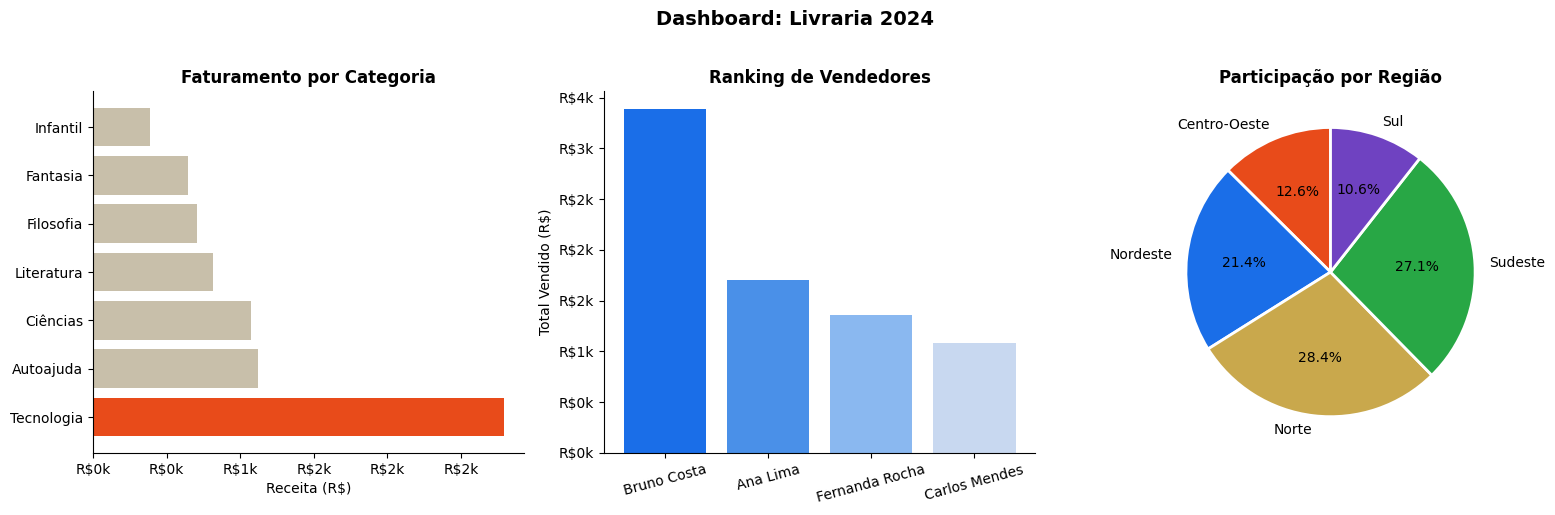

✅ Gráficos salvos em dashboard_livraria.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dashboard: Livraria 2024",
             fontsize=14, fontweight="bold", y=1.02)

ax1 = axes[0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

ax2 = axes[1]
ax2.bar(vend_rank.index, vend_rank.values,
        color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=15)

ax3 = axes[2]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index,
        autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90,
        wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

plt.tight_layout()
plt.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráficos salvos em dashboard_livraria.png")

Bibliotecas importadas com sucesso!
Dataset criado! Shape: (50, 9)
   Colunas: ['id_venda', 'data', 'produto', 'categoria', 'quantidade', 'preco_unit', 'vendedor', 'regiao', 'total_venda']

 Primeiras linhas do dataset:
   id_venda        data            produto   categoria  quantidade  \
0         1  2024-01-01      Atomic Habits   Autoajuda           3   
1         2  2024-01-04  Python para Dados  Tecnologia           1   
2         3  2024-01-08   A Arte da Guerra   Filosofia           4   
3         4  2024-01-12         Clean Code  Tecnologia           2   
4         5  2024-01-15      Atomic Habits   Autoajuda           4   

   preco_unit        vendedor        regiao  total_venda  
0        44.9        Ana Lima  Centro-Oeste        134.7  
1        89.9  Fernanda Rocha         Norte         89.9  
2        32.0     Bruno Costa  Centro-Oeste        128.0  
3        95.0     Bruno Costa      Nordeste        190.0  
4        44.9   Carlos Mendes      Nordeste        179.6  

════

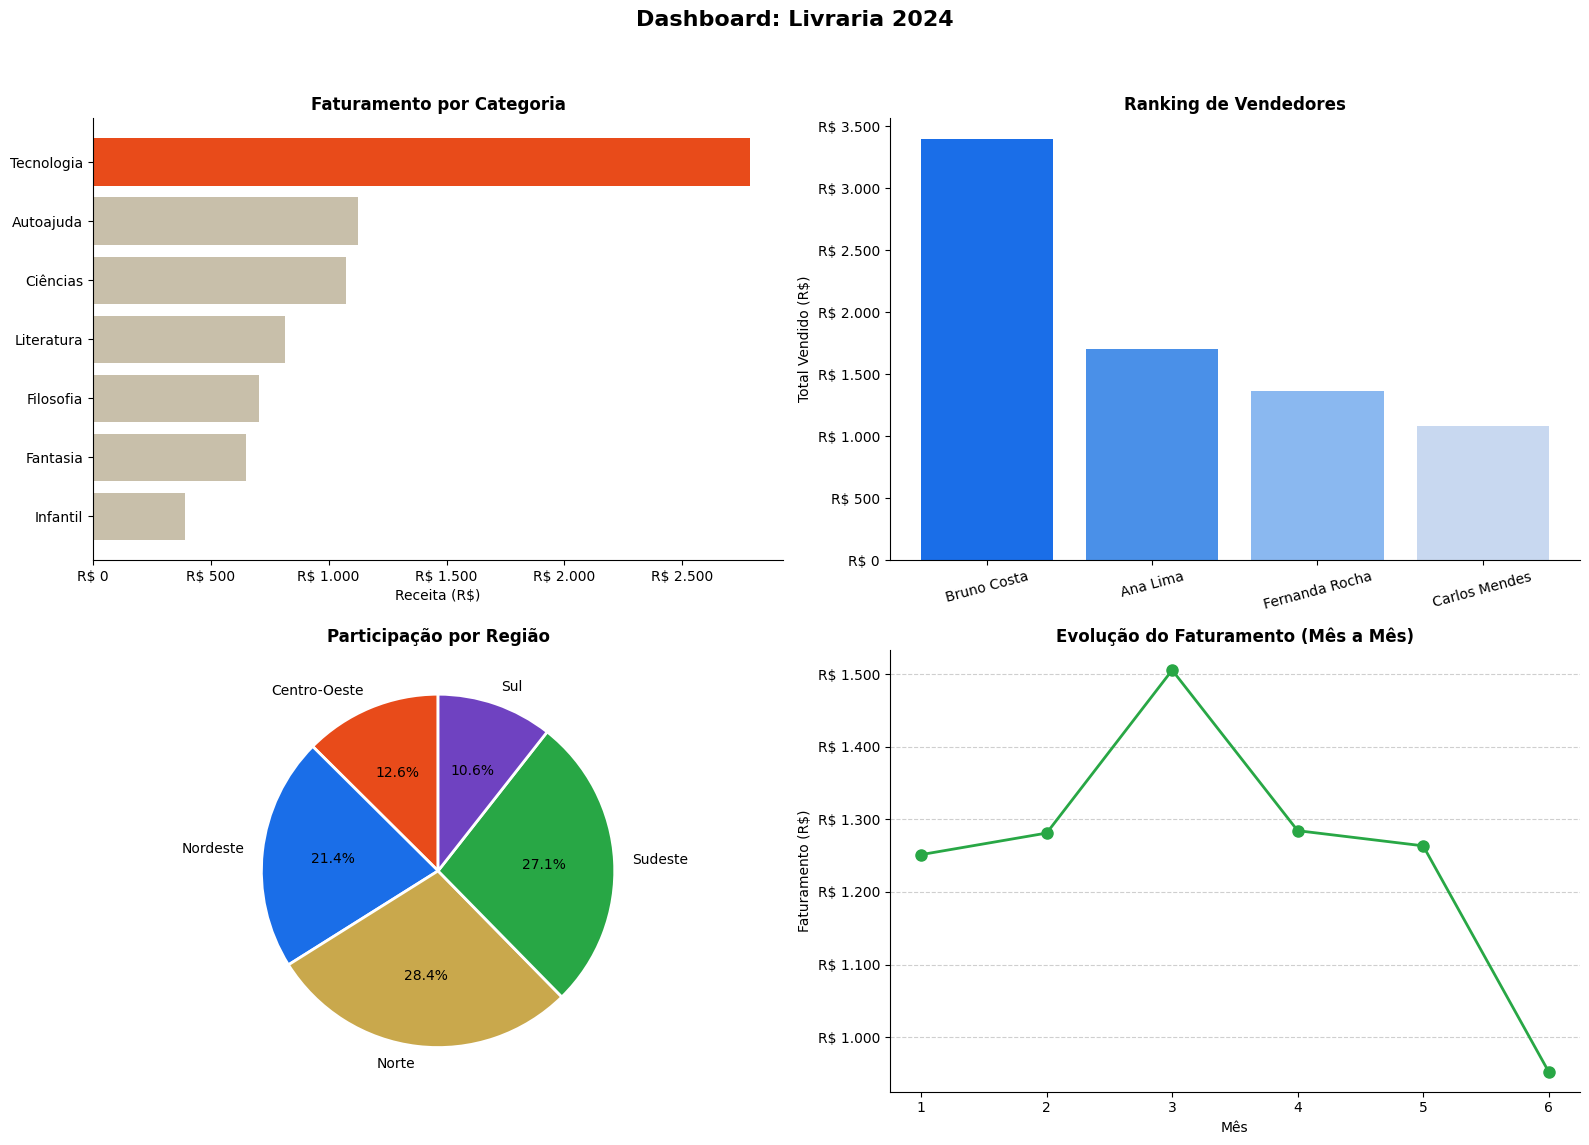

Gráficos salvos em dashboard_livraria.png


In [ ]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Bibliotecas importadas com sucesso!")

def formata_br(valor):
    """Formata um valor float para o padrão de moeda brasileiro."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":            ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]
datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

df.to_csv("vendas_livraria.csv", index=False)

print(f"Dataset criado! Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
print("\nPrimeiras linhas do dataset:")
print(df.head())

df = pd.read_csv("vendas_livraria.csv")

print("\n" + "═" * 45)
print("INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\nTIPOS DE DADOS:")
print(df.dtypes)

print("\nVALORES NULOS:")
print(df.isnull().sum())

print("\nESTATÍSTICAS DESCRITIVAS:")
print(df[["quantidade", "preco_unit", "total_venda"]].describe().round(2))

total = df["total_venda"].sum()
print(f"\nFaturamento Total: {formata_br(total)}")

print("\nFaturamento por Categoria:")
cat_fat = df.groupby("categoria")["total_venda"].sum().sort_values(ascending=False)
print(cat_fat.apply(formata_br))

print("\nRanking de Vendedores:")
vend_rank = df.groupby("vendedor")["total_venda"].sum().sort_values(ascending=False)
print(vend_rank.apply(formata_br))

print("\nTop 3 Produtos (qtd vendida):")
top_prod = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False).head(3)
print(top_prod)

print("\nTicket Médio por Região:")
reg_media = df.groupby("regiao")["total_venda"].mean().sort_values(ascending=False).round(2)
print(reg_media.apply(formata_br))

print("\nEvolução do Faturamento (Mês a Mês):")
df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.month
fat_mes = df.groupby("mes")["total_venda"].sum()
print(fat_mes.apply(formata_br))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Dashboard: Livraria 2024", fontsize=16, fontweight="bold", y=0.98)

ax1 = axes[0, 0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", ".")))
ax1.invert_yaxis()
ax2 = axes[0, 1]
ax2.bar(vend_rank.index, vend_rank.values, color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"R$ {y:,.0f}".replace(",", ".")))
ax2.tick_params(axis="x", rotation=15)

ax3 = axes[1, 0]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index, autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90, wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

ax4 = axes[1, 1]
ax4.plot(fat_mes.index, fat_mes.values, marker="o", linestyle="-", color="#28a745", linewidth=2, markersize=8)
ax4.set_title("Evolução do Faturamento (Mês a Mês)", fontweight="bold")
ax4.set_xlabel("Mês")
ax4.set_ylabel("Faturamento (R$)")
ax4.set_xticks(fat_mes.index)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"R$ {y:,.0f}".replace(",", ".")))
ax4.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráficos salvos em dashboard_livraria.png")

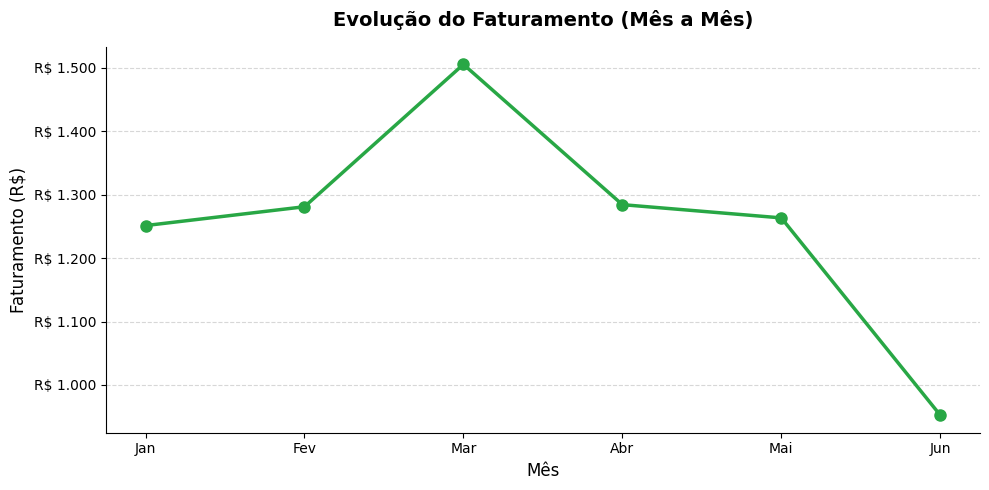

In [ ]:
df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.month
fat_mes = df.groupby("mes")["total_venda"].sum()

plt.figure(figsize=(10, 5))

plt.plot(fat_mes.index, fat_mes.values, marker="o", linestyle="-", color="#28a745", linewidth=2.5, markersize=8)

plt.title("Evolução do Faturamento (Mês a Mês)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mês", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)

meses_nomes = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun"]
plt.xticks(fat_mes.index, meses_nomes[:len(fat_mes)])

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R$ {y:,.0f}".replace(",", "."))
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
ticket_vendedores = df.groupby("vendedor")["total_venda"].mean().sort_values(ascending=False)

print("Ranking de Ticket Médio por Vendedor:")
print(ticket_vendedores.apply(formata_br))

melhor_vendedor = ticket_vendedores.index[0]
maior_ticket = ticket_vendedores.iloc[0]

print("-" * 45)
print(f"O vendedor com o maior ticket médio é: **{melhor_vendedor}**")
print(f"Média por venda: {formata_br(maior_ticket)}")
print("-" * 45)

Ranking de Ticket Médio por Vendedor:
vendedor
Bruno Costa       R$ 161,57
Fernanda Rocha    R$ 151,23
Ana Lima          R$ 141,73
Carlos Mendes     R$ 135,45
Name: total_venda, dtype: object
---------------------------------------------
O vendedor com o maior ticket médio é: **Bruno Costa**
Média por venda: R$ 161,57
---------------------------------------------


In [ ]:
vendas_alto_valor = df[df["total_venda"] > 200]

fat_alto_valor = vendas_alto_valor.groupby("categoria")["total_venda"].sum().sort_values(ascending=False)

qtd_alto_valor = vendas_alto_valor["categoria"].value_counts()

print("ANÁLISE DE VENDAS VIP (> R$ 200)")
print("-" * 45)
print(f"Total de transações de alto valor encontradas: {len(vendas_alto_valor)}")

print("\nFaturamento Dominante por Categoria:")
print(fat_alto_valor.apply(formata_br))

print("\nQuantidade de Transações VIP por Categoria:")
print(qtd_alto_valor)

ANÁLISE DE VENDAS VIP (> R$ 200)
---------------------------------------------
Total de transações de alto valor encontradas: 8

Faturamento Dominante por Categoria:
categoria
Tecnologia    R$ 1.859,20
Ciências        R$ 250,00
Fantasia        R$ 249,50
Autoajuda       R$ 224,50
Name: total_venda, dtype: object

Quantidade de Transações VIP por Categoria:
categoria
Tecnologia    5
Fantasia      1
Ciências      1
Autoajuda     1
Name: count, dtype: int64


In [ ]:
linhas_nulas = pd.DataFrame({
    "id_venda":   [51, 52, 53, 54, 55],
    "data":       ["2024-07-01", "2024-07-02", np.nan, "2024-07-04", np.nan],
    "produto":    ["Sapiens", np.nan, "Cosmos", np.nan, "Clean Code"],
    "categoria":  ["Ciências", np.nan, "Ciências", np.nan, "Tecnologia"],
    "quantidade": [2, np.nan, 1, 4, np.nan],
    "preco_unit": [54.90, np.nan, 62.50, np.nan, 95.00],
    "vendedor":   ["Ana Lima", "Carlos Mendes", np.nan, "Bruno Costa", np.nan],
    "regiao":     ["Sudeste", "Sul", "Nordeste", np.nan, np.nan],
    "total_venda":[109.80, np.nan, 62.50, np.nan, np.nan]
})

df = pd.concat([df, linhas_nulas], ignore_index=True)

print("Novas linhas com valores nulos adicionadas!")

print("\nIDENTIFICANDO VALORES NULOS:")

nulos_por_coluna = df.isnull().sum()
print(nulos_por_coluna[nulos_por_coluna > 0])


print("\nTRATANDO OS DADOS:")

colunas_texto = ["produto", "categoria", "vendedor", "regiao"]
df[colunas_texto] = df[colunas_texto].fillna("Não Informado")

df["quantidade"] = df["quantidade"].fillna(1)

media_preco = df["preco_unit"].mean()
df["preco_unit"] = df["preco_unit"].fillna(media_preco)

df["total_venda"] = df["quantidade"] * df["preco_unit"]

tamanho_antes = df.shape[0]

df = df.dropna(subset=["data"])

tamanho_depois = df.shape[0]
linhas_removidas = tamanho_antes - tamanho_depois

print(f"Textos vazios preenchidos com 'Não Informado'.")
print(f"Quantidades vazias preenchidas com '1'.")
print(f"Preços vazios preenchidos com a média (R$ {media_preco:.2f}).")
print(f"Linhas removidas por falta de data: {linhas_removidas}")

print("\nSTATUS FINAL DE NULOS:")
print(df.isnull().sum())

Novas linhas com valores nulos adicionadas!

IDENTIFICANDO VALORES NULOS:
data           2
produto        2
categoria      2
quantidade     2
preco_unit     2
vendedor       2
regiao         2
total_venda    3
mes            8
dtype: int64

TRATANDO OS DADOS:
Textos vazios preenchidos com 'Não Informado'.
Quantidades vazias preenchidas com '1'.
Preços vazios preenchidos com a média (R$ 56.40).
Linhas removidas por falta de data: 2

STATUS FINAL DE NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
mes            6
dtype: int64
